###### 今まで見てきたニューラルネットワークは「フィードフォワード」と呼ばれるタイプの流れが一方向のネットワーク
###### しかし、時系列データをうまく扱えないという問題を持つ
###### → この問題を解決したのが RNN（Recurrent Neural Network）

#####
##### 言語モデル
###### 単語の並びに対して、確率（それがどれだけ起こりうるのか）を与える。
###### 自然な単語の並びには高い確率を、不自然な並びには低い確率を出力する
######
###### 数式を使って言語モデルを記述する。
###### $w_1,...,w_m$という$m$個の単語からなる文章について考える。
###### このとき、$w_1,...,w_m$という順序で単語が出現する確率は、
###### $$P(w_1,...,w_m)$$
###### この確率は複数の事象が同時に起こる確率でもあるため、同時確率と呼ばれる
###### 確率の乗法定理より、
###### $$P(w_1,...,w_m) = \prod_{t=1}^{m} P(w_t | w_1,...,w_{t-1}) $$

###### 
###### word2vecのCBOWモデルを（無理やり）言語モデルに適用すると、
###### $$P(w_1,...,w_m) = \prod_{t=1}^{m} P(w_t | w_1,...,w_{t-1}) = \prod_{t=1}^{m} P(w_t | w_{t-2},w_{t-1}) $$
###### コンテキストを左側の2単語に限定することで、近似的にCBOWで表せる
###### しかし、コンテキストよりもさらに左側にある情報は無視されてしまう、
###### コンテキストのサイズを大きくしても、コンテキスト内の単語の並びが無視される、
###### といった問題点を持つ
######
###### 補足：
###### 機械学習や統計学の分野では、未来の状態が現在の状態だけに依存して決まることを「マルコフ性」という。
###### また、ある事象の確率がその直前のNこの事象だけに依存するとき、これを「N階マルコフ連鎖」という。
###### ここで示したモデルは「2階マルコフ連鎖」と呼ぶことができる。

####
##### RNN（Recurrent Neural Network）
###### Recurrentとは「循環する」という意味
###### RNNはループする経路（閉じた経路）を持つという特徴がある。
###### データが循環することで、過去の情報を記憶しながら、最新のデータへと更新することができる。
######
###### RNNレイヤのループを展開することで、フィードフォワード型ニューラルネットワークと同じ構造で表せる
###### 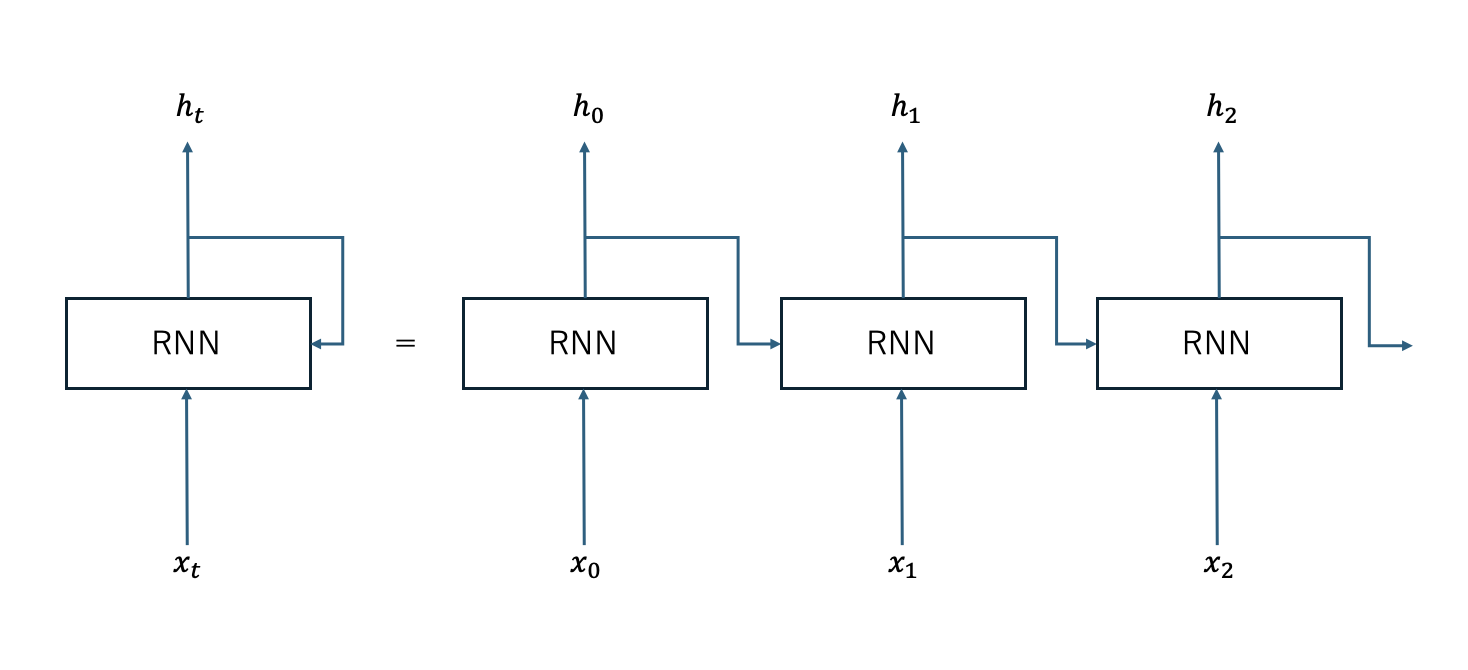
###### 各時刻のRNNレイヤは、そのレイヤへの入力$x_t$と、一つ前のRNNレイヤからの出力$H_{t-1}$を受け取り、その2つの情報をもとに、その時刻の出力が計算される。
###### $$ h_t = tanh(h_{t-1}W_h+x_tW_x+b) $$
###### なお、$_{t-1}とx_t$は行ベクトルとする
###### 式を見ると、現在の出力()は、一つ前の出力()によって計算されていることがわかる。
###### これは、RNNはhという「状態」を持っており、上式の形で更新されると解釈できる。
###### RNNの$h_t$は「隠れ状態」や「隠れ状態ベクトル」と呼ばれる

######
###### ループを展開した後のRNNは（通常の）誤差逆伝播法を使うことができる。
###### つまり、最初に順伝播を行い、続いて逆伝播を行うことで目的の勾配を求めることができる。
###### ここでの誤差逆伝播法を、「時間方向に展開したニューラルネットワークの誤差逆伝播法」ということで
###### BPTT(Backpropagation Through Time)と呼ばれる
######
###### しかし、長い時系列データを扱う場合、計算リソースの増加や、逆伝播時の勾配が不安定になるなどの問題がある
###### これを解決する手法が Truncated BPTT 
###### 逆伝播のつながりを適当な長さで切り取り、小さなネットワークを複数作る。
###### （順伝播のつながりは維持されたまま）
######
###### Truncated BPTT のミニバッチ学習では、
###### ・データをシーケンシャルに与えること
###### ・各パッチでデータを与える開始位置をずらすこと(途中で終端に達したら、先頭に戻る)
###### のようにデータを与える

######
###### RNNLM:RNN Language Model

#####
##### 言語モデルの評価
###### パープレキシティという指標を用いて、予測性能を評価する
######
###### ・入力データが一つの場合
###### 「確率の逆数」がパープレキシティを表す
###### ex) 
###### 確率0.8のパープレキシティは$\frac{1}{0.8}=1.25$
###### 確率0.2のパープレキシティは$\frac{1}{0.2}=5$
###### これは、「分岐数」次に出現しうる単語の候補の数 として解釈できる
###### 良いもモデルほどパープレキシティは小さい（最小は1）
######
###### ・入力データが複数の場合
###### $$ L = -\frac{1}{N} \sum_{n} \sum_{k} t_{nk} logy_{nk} $$
###### $$ perplexity = e^L $$
###### データが$N$個。$t_n$はone-hotベクトルの正解ラベルで、$t_{nk}$は$n$個目のデータの$k$番目の値を意味する。$y_{nk}$は確率分布を表す。

######
###### パープレキシティの推移
###### 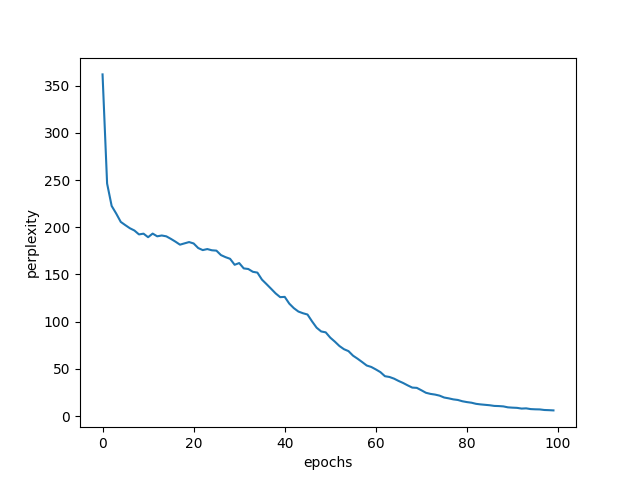